## Librerías

In [2]:
import os
import json
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import HistGradientBoostingRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import mlflow
import mlflow.keras

warnings.filterwarnings('ignore')

# Reproducibilidad
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style='whitegrid', palette='muted')
AZUL   = '#2c5f8a'
ROJO   = '#c0392b'
VERDE  = '#27ae60'

# Carpetas de salida
ARTIFACT_DIR = Path('artifacts_regresion')
FIG_DIR = Path('figures_regresion')
ARTIFACT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

In [3]:
import sys
print(sys.executable)
import tensorflow as tf

print(tf.__version__)



/Users/jeronimoruedar/Desktop/Octavo Semestre/Analítica Computacional/Proyectos/P2/Proyecto-2/venv/bin/python
2.16.2


## 1. Carga de datos

In [4]:
DATA_PATH = '/Users/jeronimoruedar/Desktop/Octavo Semestre/Analítica Computacional/Proyectos/P2/Saber 11 Datos Valle.csv'

df = pd.read_csv(DATA_PATH, low_memory=False)
df.head()

,PERIODO,ESTU_TIPODOCUMENTO,ESTU_CONSECUTIVO,COLE_AREA_UBICACION,COLE_BILINGUE,COLE_CALENDARIO,COLE_CARACTER,COLE_COD_DANE_ESTABLECIMIENTO,COLE_COD_DANE_SEDE,COLE_COD_DEPTO_UBICACION,...,FAMI_TIENECOMPUTADOR,FAMI_TIENEINTERNET,FAMI_TIENELAVADORA,DESEMP_INGLES,PUNT_INGLES,PUNT_MATEMATICAS,PUNT_SOCIALES_CIUDADANAS,PUNT_C_NATURALES,PUNT_LECTURA_CRITICA,PUNT_GLOBAL
0,20162,TI,SB11201620084846,URBANO,N,A,TÉCNICO/ACADÉMICO,1.760010e+11,1.760010e+11,76,...,Si,Si,Si,A2,59.00,57.00,46.0,57.0,57.0,272.0
1,20142,TI,SB11201420437853,URBANO,N,A,ACADÉMICO,1.768950e+11,1.768950e+11,76,...,Si,No,Si,A-,48.00,45.00,29.0,45.0,38.0,200.0
2,20111,TI,SB11201110031540,URBANO,N,B,ACADÉMICO,3.760010e+11,3.760010e+11,76,...,Si,Si,Si,B1,79.55,60.14,NaN,NaN,NaN,NaN
3,20122,TI,SB11201220211394,URBANO,N,A,TÉCNICO/ACADÉMICO,3.760010e+11,3.760010e+11,76,...,Si,No,Si,A-,40.00,49.00,NaN,NaN,NaN,NaN
4,20132,TI,SB11201320371098,URBANO,N,A,TÉCNICO/ACADÉMICO,1.760010e+11,1.760010e+11,76,...,No,No,Si,A-,37.00,46.00,NaN,NaN,NaN,NaN


In [ ]:
df.shape

## 2. Seleccion de variables y variable objetivo

In [5]:
FEATURES = [
    'FAMI_ESTRATOVIVIENDA',
    'FAMI_EDUCACIONPADRE',
    'FAMI_EDUCACIONMADRE',
    'FAMI_TIENEINTERNET',
    'FAMI_TIENECOMPUTADOR',
    'FAMI_TIENELAVADORA',
    'COLE_BILINGUE',
    'COLE_JORNADA',
    'COLE_NATURALEZA',
    'COLE_AREA_UBICACION'
]

TARGET = 'PUNT_GLOBAL'

df_model = df[FEATURES + [TARGET]].dropna().copy()

print(df_model[TARGET].describe().round(2))

count    322030.00
mean        256.97
std          50.14
min           0.00
25%         220.00
50%         253.00
75%         291.00
max         495.00
Name: PUNT_GLOBAL, dtype: float64


## 3. Análisis exploratorio

### Distribucion del puntaje

In [ ]:

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df_model[TARGET], bins=60, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(df_model[TARGET].mean(), color='red', linestyle='--',
           linewidth=2, label=f'Media: {df_model[TARGET].mean():.1f}')
ax.axvline(df_model[TARGET].median(), color='orange', linestyle='--',
           linewidth=2, label=f'Mediana: {df_model[TARGET].median():.1f}')
ax.set_title('Distribución de PUNT_GLOBAL', fontsize=13)
ax.set_xlabel('Puntaje Global')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.tight_layout()
plt.savefig('distribucion_target.png', dpi=150, bbox_inches='tight')
plt.show()

### Codificación de variables

In [7]:
ORDINAL_MAPS = {
    'FAMI_ESTRATOVIVIENDA': {
        'Estrato 1': 1, 'Estrato 2': 2, 'Estrato 3': 3,
        'Estrato 4': 4, 'Estrato 5': 5, 'Estrato 6': 6,
        'Sin Estrato': 0
    },
    'FAMI_EDUCACIONPADRE': {
        'Ninguno': 0, 'Primaria incompleta': 1, 'Primaria completa': 2,
        'Secundaria (Bachillerato) incompleta': 3,
        'Secundaria (Bachillerato) completa': 4,
        'Técnica o tecnológica incompleta': 5,
        'Técnica o tecnológica completa': 6,
        'Educación profesional incompleta': 7,
        'Educación profesional completa': 8,
        'Postgrado': 9, 'No sabe': -1
    },
    'FAMI_EDUCACIONMADRE': {
        'Ninguno': 0, 'Primaria incompleta': 1, 'Primaria completa': 2,
        'Secundaria (Bachillerato) incompleta': 3,
        'Secundaria (Bachillerato) completa': 4,
        'Técnica o tecnológica incompleta': 5,
        'Técnica o tecnológica completa': 6,
        'Educación profesional incompleta': 7,
        'Educación profesional completa': 8,
        'Postgrado': 9, 'No sabe': -1
    },
    'FAMI_TIENEINTERNET':   {'Si': 1, 'No': 0},
    'FAMI_TIENECOMPUTADOR': {'Si': 1, 'No': 0},
    'FAMI_TIENELAVADORA':   {'Si': 1, 'No': 0},
    'COLE_BILINGUE':        {'S': 1, 'N': 0},
    'COLE_NATURALEZA':      {'NO OFICIAL': 1, 'OFICIAL': 0},
    'COLE_AREA_UBICACION':  {'URBANO': 1, 'RURAL': 0},
    'COLE_JORNADA': {
        'COMPLETA': 4, 'MAÑANA': 3, 'TARDE': 2,
        'UNICA': 3, 'NOCHE': 1, 'SABATINA': 0
    }
}

df_enc = df_model.copy()
for col, mapping in ORDINAL_MAPS.items():
    if col in df_enc.columns:
        df_enc[col] = df_enc[col].map(mapping)
        df_enc[col] = df_enc[col].fillna(df_enc[col].median())


df_enc[FEATURES].head(3)

,FAMI_ESTRATOVIVIENDA,FAMI_EDUCACIONPADRE,FAMI_EDUCACIONMADRE,FAMI_TIENEINTERNET,FAMI_TIENECOMPUTADOR,FAMI_TIENELAVADORA,COLE_BILINGUE,COLE_JORNADA,COLE_NATURALEZA,COLE_AREA_UBICACION
0,5,4.0,3.0,1,1,1,0,3,0,1
1,2,2.0,3.0,0,1,1,0,3,0,1
10,3,3.0,4.0,1,1,1,0,3,0,1


### Correlacion de variables con puntaje global

In [ ]:
pearson  = [stats.pearsonr(df_enc[f],  df_enc[TARGET])[0] for f in FEATURES]
spearman = [stats.spearmanr(df_enc[f], df_enc[TARGET])[0] for f in FEATURES]

corr_df = pd.DataFrame({
    'Feature':  FEATURES,
    'Pearson':  pearson,
    'Spearman': spearman
}).sort_values('Spearman', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(corr_df))
w = 0.35
ax.barh(x - w/2, corr_df['Pearson'],  w, label='Pearson',  color=AZUL,  alpha=0.85)
ax.barh(x + w/2, corr_df['Spearman'], w, label='Spearman', color=ROJO, alpha=0.85)
ax.set_yticks(x)
ax.set_yticklabels(corr_df['Feature'], fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlación con PUNT_GLOBAL')
ax.set_title('Correlación de variables predictoras con el puntaje global', fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig('correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()

print(corr_df.sort_values('Spearman', ascending=False).to_string(index=False))

### Puntaje promedio por categoría de cada variable

In [ ]:

VAR_LABELS = {
    'FAMI_ESTRATOVIVIENDA': 'Estrato',
    'FAMI_EDUCACIONPADRE':  'Educación Padre',
    'FAMI_EDUCACIONMADRE':  'Educación Madre',
    'FAMI_TIENEINTERNET':   'Internet',
    'FAMI_TIENECOMPUTADOR': 'Computador',
    'FAMI_TIENELAVADORA':   'Lavadora',
    'COLE_BILINGUE':        'Colegio Bilingüe',
    'COLE_JORNADA':         'Jornada',
    'COLE_NATURALEZA':      'Naturaleza Colegio',
    'COLE_AREA_UBICACION':  'Área Colegio'
}

# Ordenar educación por nivel
ORDEN_EDU = [
    'Ninguno', 'Primaria incompleta', 'Primaria completa',
    'Secundaria (Bachillerato) incompleta', 'Secundaria (Bachillerato) completa',
    'Técnica o tecnológica incompleta', 'Técnica o tecnológica completa',
    'Educación profesional incompleta', 'Educación profesional completa',
    'Postgrado'
]

fig, axes = plt.subplots(5, 2, figsize=(15, 22))
axes = axes.flatten()

for idx, (col, label) in enumerate(VAR_LABELS.items()):
    agg = df_model.groupby(col)[TARGET].agg(['mean', 'std', 'count']).reset_index()

    # Ordenar variables de educación
    if col in ('FAMI_EDUCACIONPADRE', 'FAMI_EDUCACIONMADRE'):
        agg[col] = pd.Categorical(agg[col], categories=ORDEN_EDU, ordered=True)
        agg = agg.sort_values(col)

    ax = axes[idx]
    bars = ax.bar(range(len(agg)), agg['mean'], color=AZUL, alpha=0.85, zorder=2)
    ax.errorbar(range(len(agg)), agg['mean'], yerr=agg['std'],
                fmt='none', color='gray', capsize=4, linewidth=1.2, zorder=3)

    # Etiqueta con n
    for i, (_, row) in enumerate(agg.iterrows()):
        ax.text(i, row['mean'] + row['std'] + 1,
                f"n={int(row['count']):,}", ha='center', fontsize=6.5, color='dimgray')

    ax.set_xticks(range(len(agg)))
    ax.set_xticklabels(agg[col].astype(str), rotation=35, ha='right', fontsize=8)
    ax.set_title(f'PUNT_GLOBAL promedio por {label}', fontsize=10)
    ax.set_ylabel('Puntaje promedio')
    ax.set_ylim(200, agg['mean'].max() + agg['std'].max() + 20)
    ax.grid(axis='y', alpha=0.4)

plt.suptitle('Puntaje Global promedio (±1 std) por categoría de cada variable', 
             fontsize=14, y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig('promedios_por_categoria.png', dpi=150, bbox_inches='tight')
plt.show()

### Violin plots por promedio del puntajee de los padres para cada estratp

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Violin por estrato
estratos_validos = ['Estrato 1','Estrato 2','Estrato 3',
                    'Estrato 4','Estrato 5','Estrato 6']
df_est = df_model[df_model['FAMI_ESTRATOVIVIENDA'].isin(estratos_validos)]

sns.violinplot(
    data=df_est, x='FAMI_ESTRATOVIVIENDA', y=TARGET,
    order=estratos_validos, palette='Blues', inner='box', ax=axes[0]
)
axes[0].set_title('Distribución PUNT_GLOBAL por Estrato', fontsize=12)
axes[0].set_xlabel('Estrato')
axes[0].set_ylabel('Puntaje Global')

# Violin por educación combinada de padres (promedio )
df_enc2 = df_model.copy()
df_enc2['edu_padre_n'] = df_enc2['FAMI_EDUCACIONPADRE'].map(ORDINAL_MAPS['FAMI_EDUCACIONPADRE'])
df_enc2['edu_madre_n'] = df_enc2['FAMI_EDUCACIONMADRE'].map(ORDINAL_MAPS['FAMI_EDUCACIONMADRE'])
df_enc2['edu_padres']  = ((df_enc2['edu_padre_n'] + df_enc2['edu_madre_n']) / 2).round().astype('Int64')

etiquetas_edu = {
    0: 'Ninguno', 1: 'Prim. inc.', 2: 'Prim. comp.',
    3: 'Sec. inc.', 4: 'Sec. comp.', 5: 'Téc. inc.',
    6: 'Téc. comp.', 7: 'Prof. inc.', 8: 'Prof. comp.', 9: 'Postgrado'
}
df_enc2['edu_label'] = df_enc2['edu_padres'].map(etiquetas_edu)
orden_labels = [etiquetas_edu[i] for i in sorted(etiquetas_edu.keys())]
df_enc2_valid = df_enc2[df_enc2['edu_label'].notna()]

sns.violinplot(
    data=df_enc2_valid, x='edu_label', y=TARGET,
    order=orden_labels, palette='Oranges', inner='box', ax=axes[1]
)
axes[1].set_title('Distribución PUNT_GLOBAL por Nivel Educativo Promedio (Padres)', fontsize=12)
axes[1].set_xlabel('Educación promedio padres')
axes[1].set_ylabel('Puntaje Global')
axes[1].tick_params(axis='x', rotation=40)

plt.tight_layout()
plt.savefig('violines_estrato_educacion.png', dpi=150, bbox_inches='tight')
plt.show()

### Heatmap de educacion promedio padres vs estrato

In [ ]:

df_heat = df_enc2_valid.copy()
df_heat = df_heat[df_heat['FAMI_ESTRATOVIVIENDA'].isin(estratos_validos)]

pivot = df_heat.pivot_table(
    values=TARGET,
    index='FAMI_ESTRATOVIVIENDA',
    columns='edu_label',
    aggfunc='mean'
).reindex(index=estratos_validos, columns=orden_labels)

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    pivot, annot=True, fmt='.0f', cmap='YlOrRd',
    linewidths=0.4, linecolor='white',
    ax=ax, cbar_kws={'label': 'PUNT_GLOBAL promedio'}
)
ax.set_title('Puntaje Global promedio — Estrato × Educación promedio padres', fontsize=13)
ax.set_xlabel('Educación promedio padres')
ax.set_ylabel('Estrato')
ax.tick_params(axis='x', rotation=40)
plt.tight_layout()
plt.savefig('heatmap_estrato_educacion.png', dpi=150, bbox_inches='tight')
plt.show()

### Slopchart de cada variable para el puntaje total

In [ ]:
SLOPE_VARS = {
    'Estrato (1 vs 6)': (
        df_model[df_model['FAMI_ESTRATOVIVIENDA']=='Estrato 1'][TARGET].mean(),
        df_model[df_model['FAMI_ESTRATOVIVIENDA']=='Estrato 6'][TARGET].mean()
    ),
    'Educ. Padre (Ninguno vs Postgrado)': (
        df_model[df_model['FAMI_EDUCACIONPADRE']=='Ninguno'][TARGET].mean(),
        df_model[df_model['FAMI_EDUCACIONPADRE']=='Postgrado'][TARGET].mean()
    ),
    'Educ. Madre (Ninguno vs Postgrado)': (
        df_model[df_model['FAMI_EDUCACIONMADRE']=='Ninguno'][TARGET].mean(),
        df_model[df_model['FAMI_EDUCACIONMADRE']=='Postgrado'][TARGET].mean()
    ),
    'Internet (No vs Sí)': (
        df_model[df_model['FAMI_TIENEINTERNET']=='No'][TARGET].mean(),
        df_model[df_model['FAMI_TIENEINTERNET']=='Si'][TARGET].mean()
    ),
    'Computador (No vs Sí)': (
        df_model[df_model['FAMI_TIENECOMPUTADOR']=='No'][TARGET].mean(),
        df_model[df_model['FAMI_TIENECOMPUTADOR']=='Si'][TARGET].mean()
    ),
    'Lavadora (No vs Sí)': (
        df_model[df_model['FAMI_TIENELAVADORA']=='No'][TARGET].mean(),
        df_model[df_model['FAMI_TIENELAVADORA']=='Si'][TARGET].mean()
    ),
    'Bilingüe (No vs Sí)': (
        df_model[df_model['COLE_BILINGUE']=='N'][TARGET].mean(),
        df_model[df_model['COLE_BILINGUE']=='S'][TARGET].mean()
    ),
    'Naturaleza (Oficial vs No Oficial)': (
        df_model[df_model['COLE_NATURALEZA']=='OFICIAL'][TARGET].mean(),
        df_model[df_model['COLE_NATURALEZA']=='NO OFICIAL'][TARGET].mean()
    ),
    'Jornada (Sabatina vs Completa)': (
        df_model[df_model['COLE_JORNADA']=='SABATINA'][TARGET].mean(),
        df_model[df_model['COLE_JORNADA']=='COMPLETA'][TARGET].mean()
    ),
    'Área (Rural vs Urbano)': (
        df_model[df_model['COLE_AREA_UBICACION']=='RURAL'][TARGET].mean(),
        df_model[df_model['COLE_AREA_UBICACION']=='URBANO'][TARGET].mean()
    ),
}

slope_df = pd.DataFrame(SLOPE_VARS, index=['Extremo bajo', 'Extremo alto']).T
slope_df['Delta'] = slope_df['Extremo alto'] - slope_df['Extremo bajo']
slope_df = slope_df.sort_values('Delta', ascending=False)

fig, ax = plt.subplots(figsize=(9, 9))
palette = plt.cm.tab10.colors

for i, (var, row) in enumerate(slope_df.iterrows()):
    color = palette[i % len(palette)]
    ax.plot([0, 1], [row['Extremo bajo'], row['Extremo alto']],
            'o-', color=color, linewidth=2, markersize=7, label=var)
    ax.text(1.02, row['Extremo alto'],
            f"{var}  Δ={row['Delta']:.1f}",
            va='center', fontsize=8.5, color=color)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Extremo bajo', 'Extremo alto'], fontsize=11)
ax.set_ylabel('PUNT_GLOBAL promedio', fontsize=11)
ax.set_title('Slope chart — Impacto marginal de cada variable en el puntaje global', fontsize=12)
ax.set_xlim(-0.1, 1.6)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('slope_chart.png', dpi=150, bbox_inches='tight')
plt.show()

### efecto de la tecnologia 

In [ ]:


TECH_VARS = [
    ('FAMI_TIENEINTERNET',   'Internet'),
    ('FAMI_TIENECOMPUTADOR', 'Computador'),
    ('FAMI_TIENELAVADORA',   'Lavadora'),
]

df_tech = df_model[df_model['FAMI_ESTRATOVIVIENDA'].isin(estratos_validos)].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, (col, titulo) in zip(axes, TECH_VARS):
    piv = df_tech.pivot_table(
        values=TARGET,
        index='FAMI_ESTRATOVIVIENDA',
        columns=col,
        aggfunc='mean'
    ).reindex(estratos_validos)

    x = np.arange(len(estratos_validos))
    w = 0.35
    ax.bar(x - w/2, piv.get('No', [0]*6), w, label='No', color='#aec6cf', alpha=0.9)
    ax.bar(x + w/2, piv.get('Si', [0]*6), w, label='Sí', color=AZUL,    alpha=0.9)

    ax.set_xticks(x)
    ax.set_xticklabels([e.replace('Estrato ', 'E') for e in estratos_validos])
    ax.set_title(f'{titulo}: puntaje por estrato', fontsize=11)
    ax.set_xlabel('Estrato')
    ax.set_ylabel('PUNT_GLOBAL promedio')
    ax.legend(title=titulo)
    ax.set_ylim(220, 340)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Impacto de la tecnología en el hogar dentro de cada estrato', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('tecnologia_por_estrato.png', dpi=150, bbox_inches='tight')
plt.show()

### Educacion promedio padres vs puntaje, coloreado por estrato

In [ ]:


df_sc = df_enc2_valid[df_enc2_valid['FAMI_ESTRATOVIVIENDA'].isin(estratos_validos)].copy()
df_sc['edu_num'] = (df_sc['edu_padre_n'].fillna(0) + df_sc['edu_madre_n'].fillna(0)) / 2

COLORES_ESTRATO = {
    'Estrato 1': '#d73027', 'Estrato 2': '#fc8d59',
    'Estrato 3': '#fee090', 'Estrato 4': '#91bfdb',
    'Estrato 5': '#4575b4', 'Estrato 6': '#1a237e'
}

fig, ax = plt.subplots(figsize=(11, 6))

for estrato in estratos_validos:
    sub = df_sc[df_sc['FAMI_ESTRATOVIVIENDA'] == estrato]
    ax.scatter(sub['edu_num'], sub[TARGET],
               alpha=0.15, s=6, color=COLORES_ESTRATO[estrato], label=estrato)

# Línea de tendencia global
m, b, r, p, _ = stats.linregress(df_sc['edu_num'], df_sc[TARGET])
x_line = np.linspace(df_sc['edu_num'].min(), df_sc['edu_num'].max(), 100)
ax.plot(x_line, m * x_line + b, color='black', linewidth=2.5,
        label=f'Tendencia global (r={r:.2f})', zorder=5)

ax.set_xlabel('Educación promedio padres (escala 0–9)', fontsize=11)
ax.set_ylabel('PUNT_GLOBAL', fontsize=11)
ax.set_title('Educación promedio de los padres vs Puntaje Global — coloreado por estrato',
             fontsize=12)
ax.legend(markerscale=3, fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('scatter_educacion_estrato.png', dpi=150, bbox_inches='tight')
plt.show()

### Matriz de correlación entre todas las variables

In [ ]:

LABELS_CORTAS = {
    'FAMI_ESTRATOVIVIENDA': 'Estrato',
    'FAMI_EDUCACIONPADRE':  'Educ. Padre',
    'FAMI_EDUCACIONMADRE':  'Educ. Madre',
    'FAMI_TIENEINTERNET':   'Internet',
    'FAMI_TIENECOMPUTADOR': 'Computador',
    'FAMI_TIENELAVADORA':   'Lavadora',
    'COLE_BILINGUE':        'Bilingüe',
    'COLE_JORNADA':         'Jornada',
    'COLE_NATURALEZA':      'Naturaleza',
    'COLE_AREA_UBICACION':  'Área',
    'PUNT_GLOBAL':          'PUNT_GLOBAL'
}

df_corr = df_enc[FEATURES + [TARGET]].rename(columns=LABELS_CORTAS)
corr_matrix = df_corr.corr(method='spearman')

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    ax=ax, cbar_kws={'label': 'Correlación de Spearman'}
)
ax.set_title('Matriz de correlación (Spearman) — variables del modelo', fontsize=12)
plt.tight_layout()
plt.savefig('matriz_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Alistamiento para modelo de regresión

In [8]:
X = df_enc[FEATURES].values
y = df_enc[TARGET].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED
)

print(f'Train : {X_train.shape[0]:,}')
print(f'Val   : {X_val.shape[0]:,}')
print(f'Test  : {X_test.shape[0]:,}')

# Estandarización de features: fit solo en train
scaler_X = StandardScaler()
X_train_sc = scaler_X.fit_transform(X_train)
X_val_sc   = scaler_X.transform(X_val)
X_test_sc  = scaler_X.transform(X_test)

# Estandarización del target: mejora la convergencia de la red neuronal
scaler_y = StandardScaler()
y_train_sc = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_val_sc   = scaler_y.transform(y_val.reshape(-1, 1)).ravel()
y_test_sc  = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

# Arrays limpios para TensorFlow
X_train_tf = np.ascontiguousarray(X_train_sc).astype('float32')
X_val_tf   = np.ascontiguousarray(X_val_sc).astype('float32')
X_test_tf  = np.ascontiguousarray(X_test_sc).astype('float32')

y_train_tf = np.ascontiguousarray(y_train_sc).astype('float32').reshape(-1, 1)
y_val_tf   = np.ascontiguousarray(y_val_sc).astype('float32').reshape(-1, 1)
y_test_tf  = np.ascontiguousarray(y_test_sc).astype('float32').reshape(-1, 1)

print('X_train_tf:', X_train_tf.shape, X_train_tf.dtype)
print('y_train_tf:', y_train_tf.shape, y_train_tf.dtype)
print('X_val_tf:  ', X_val_tf.shape, X_val_tf.dtype)
print('y_val_tf:  ', y_val_tf.shape, y_val_tf.dtype)
print('X_test_tf: ', X_test_tf.shape, X_test_tf.dtype)
print('y_test_tf: ', y_test_tf.shape, y_test_tf.dtype)

Train : 225,421
Val   : 48,304
Test  : 48,305
X_train_tf: (225421, 10) float32
y_train_tf: (225421, 1) float32
X_val_tf:   (48304, 10) float32
y_val_tf:   (48304, 1) float32
X_test_tf:  (48305, 10) float32
y_test_tf:  (48305, 1) float32


## 5. Modelamiento con red neuronal de regresión

In [9]:
def build_model(hidden_layers, dropout_rate, learning_rate, input_dim):
    """Construye una red neuronal feed-forward para regresión."""
    model = Sequential(name='nn_regresion_saber11')
    model.add(Dense(hidden_layers[0], activation='relu', input_shape=(input_dim,)))
    model.add(Dropout(dropout_rate))

    for units in hidden_layers[1:]:
        model.add(Dense(units, activation='relu'))
        model.add(Dropout(dropout_rate))

    # Salida lineal para regresión
    model.add(Dense(1, activation='linear'))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae']
    )
    return model


def regression_metrics(y_true, y_pred):
    """Retorna métricas de regresión en un diccionario."""
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred)
    }


def run_experiment(run_name, hidden_layers, dropout_rate, learning_rate,
                   batch_size=4096, epochs=30, patience=5,
                   use_mlflow=True, log_model=False):
    """Entrena, evalúa y opcionalmente registra un experimento en MLflow."""
    print(f'\nIniciando experimento: {run_name}', flush=True)

    model = build_model(
        hidden_layers=hidden_layers,
        dropout_rate=dropout_rate,
        learning_rate=learning_rate,
        input_dim=X_train_tf.shape[1]
    )

    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=patience,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=max(2, patience // 2),
            min_lr=1e-6,
            verbose=1
        )
    ]

    history = model.fit(
        X_train_tf,
        y_train_tf,
        validation_data=(X_val_tf, y_val_tf),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1
    )

    # Predicción y regreso a escala original
    y_pred_sc = model.predict(X_test_tf, batch_size=batch_size, verbose=1).ravel()
    y_pred = scaler_y.inverse_transform(y_pred_sc.reshape(-1, 1)).ravel()
    y_test_eval = scaler_y.inverse_transform(y_test_tf.reshape(-1, 1)).ravel()

    metrics = regression_metrics(y_test_eval, y_pred)
    metrics['epochs_trained'] = len(history.history['loss'])
    metrics['val_loss_final'] = history.history['val_loss'][-1]
    metrics['val_mae_final_scaled'] = history.history['val_mae'][-1]

    print(
        f"[{run_name}] MAE: {metrics['MAE']:.2f} | "
        f"RMSE: {metrics['RMSE']:.2f} | R²: {metrics['R2']:.4f} | "
        f"Epochs: {metrics['epochs_trained']}",
        flush=True
    )

    if use_mlflow:
        mlflow.set_experiment('regresion_saber11_punt_global')
        with mlflow.start_run(run_name=run_name):
            mlflow.log_param('model_type', 'keras_dense_regression')
            mlflow.log_param('hidden_layers', str(hidden_layers))
            mlflow.log_param('dropout_rate', dropout_rate)
            mlflow.log_param('learning_rate', learning_rate)
            mlflow.log_param('batch_size', batch_size)
            mlflow.log_param('n_features', X_train_tf.shape[1])
            mlflow.log_param('train_size', X_train_tf.shape[0])
            mlflow.log_param('val_size', X_val_tf.shape[0])
            mlflow.log_param('test_size', X_test_tf.shape[0])

            for metric_name, metric_value in metrics.items():
                mlflow.log_metric(metric_name, float(metric_value))

            history_df = pd.DataFrame(history.history)
            history_path = ARTIFACT_DIR / f'history_{run_name}.csv'
            history_df.to_csv(history_path, index=False)
            mlflow.log_artifact(str(history_path))

            # Se deja apagado por defecto porque guardar el modelo dentro de MLflow puede ser lento en local.
            if log_model:
                mlflow.keras.log_model(model, artifact_path='model')

    return model, history, y_pred, metrics

### Prueba rápida para ver si funciona

In [10]:
model_debug, hist_debug, y_pred_debug, metrics_debug = run_experiment(
    run_name='debug_test',
    hidden_layers=[16],
    dropout_rate=0.1,
    learning_rate=1e-3,
    batch_size=4096,
    epochs=3,
    patience=2,
    use_mlflow=False
)
metrics_debug


Iniciando experimento: debug_test
Epoch 1/3
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.3940 - mae: 0.9424 - val_loss: 1.0379 - val_mae: 0.8221 - learning_rate: 0.0010
Epoch 2/3
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9735 - mae: 0.7929 - val_loss: 0.8579 - val_mae: 0.7469 - learning_rate: 0.0010
Epoch 3/3
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8630 - mae: 0.7465 - val_loss: 0.7975 - val_mae: 0.7195 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 3.
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
[debug_test] MAE: 36.05 | RMSE: 44.78 | R²: 0.2012 | Epochs: 3


{'MAE': 36.045773,
 'RMSE': 44.77541,
 'R2': 0.20119976997375488,
 'epochs_trained': 3,
 'val_loss_final': 0.7975438833236694,
 'val_mae_final_scaled': 0.7194522023200989}

### Experimentos finales

In [11]:
USE_MLFLOW = True  

experimentos = [
    {'nombre': 'nn_exp1_base',       'capas': [64, 32],       'dropout': 0.2, 'lr': 1e-3, 'batch': 4096},
    {'nombre': 'nn_exp2_mas_capas',  'capas': [128, 64, 32],  'dropout': 0.2, 'lr': 1e-3, 'batch': 4096},
    {'nombre': 'nn_exp3_mayor_drop', 'capas': [128, 64, 32],  'dropout': 0.4, 'lr': 1e-3, 'batch': 4096},
    {'nombre': 'nn_exp4_lr_bajo',    'capas': [128, 64, 32],  'dropout': 0.3, 'lr': 5e-4, 'batch': 4096},
]

resultados = {}

for exp in experimentos:
    model, hist, y_pred, metrics = run_experiment(
        run_name=exp['nombre'],
        hidden_layers=exp['capas'],
        dropout_rate=exp['dropout'],
        learning_rate=exp['lr'],
        batch_size=exp['batch'],
        epochs=30,
        patience=5,
        use_mlflow=USE_MLFLOW,
        log_model=False
    )

    resultados[exp['nombre']] = {
        'model': model,
        'history': hist,
        'y_pred': y_pred,
        'metrics': metrics,
        'params': exp
    }


Iniciando experimento: nn_exp1_base
Epoch 1/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.8258 - mae: 0.7318 - val_loss: 0.7384 - val_mae: 0.6941 - learning_rate: 0.0010
Epoch 2/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7671 - mae: 0.7056 - val_loss: 0.7322 - val_mae: 0.6911 - learning_rate: 0.0010
Epoch 3/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7556 - mae: 0.7001 - val_loss: 0.7299 - val_mae: 0.6900 - learning_rate: 0.0010
Epoch 4/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7494 - mae: 0.6976 - val_loss: 0.7281 - val_mae: 0.6889 - learning_rate: 0.0010
Epoch 5/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7467 - mae: 0.6962 - val_loss: 0.7271 - val_mae: 0.6884 - learning_rate: 0.0010
Epoch 6/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7438 - mae: 0.6948 - val_loss: 0.7263 - val_mae: 0.6882 - learning_rate: 0.0010
Epoch 7/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7432 - mae: 0.6945 - val_loss: 0.7251 - val_mae: 0.6876 - learn

2026/05/24 21:56:26 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/24 21:56:26 INFO mlflow.store.db.utils: Updating database tables
2026/05/24 21:56:26 INFO mlflow.tracking.fluent: Experiment with name 'regresion_saber11_punt_global' does not exist. Creating a new experiment.



Iniciando experimento: nn_exp2_mas_capas
Epoch 1/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.8237 - mae: 0.7292 - val_loss: 0.7397 - val_mae: 0.6966 - learning_rate: 0.0010
Epoch 2/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.7598 - mae: 0.7025 - val_loss: 0.7322 - val_mae: 0.6923 - learning_rate: 0.0010
Epoch 3/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.7523 - mae: 0.6989 - val_loss: 0.7297 - val_mae: 0.6911 - learning_rate: 0.0010
Epoch 4/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7468 - mae: 0.6964 - val_loss: 0.7286 - val_mae: 0.6906 - learning_rate: 0.0010
Epoch 5/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7445 - mae: 0.6952 - val_loss: 0.7267 - val_mae: 0.6895 - learning_rate: 0.0010
Epoch 6/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7421 - mae: 0.6942 - val_loss: 0.7258 - val_mae: 0.6889 - learning_rate: 0.0010
Epoch 7/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7399 - mae: 0.6931 - val_loss: 0.7252 - val_mae: 0.6886 

### Comparación y selección del mejor modelo

In [12]:
comparacion_nn = []
for nombre, info in resultados.items():
    row = {'experimento': nombre}
    row.update(info['params'])
    row.update(info['metrics'])
    comparacion_nn.append(row)

df_comparacion_nn = pd.DataFrame(comparacion_nn).sort_values('RMSE').reset_index(drop=True)
df_comparacion_nn

,experimento,nombre,capas,dropout,lr,batch,MAE,RMSE,R2,epochs_trained,val_loss_final,val_mae_final_scaled
0,nn_exp2_mas_capas,nn_exp2_mas_capas,"[128, 64, 32]",0.2,0.0010,4096,34.178532,42.399010,0.283740,30,0.716761,0.683464
1,nn_exp1_base,nn_exp1_base,"[64, 32]",0.2,0.0010,4096,34.279129,42.525509,0.279460,26,0.721030,0.685398
2,nn_exp3_mayor_drop,nn_exp3_mayor_drop,"[128, 64, 32]",0.4,0.0010,4096,34.467838,42.668438,0.274608,30,0.724052,0.688208
3,nn_exp4_lr_bajo,nn_exp4_lr_bajo,"[128, 64, 32]",0.3,0.0005,4096,34.750156,42.958084,0.264727,30,0.732993,0.693533


In [13]:
best_nn_name = df_comparacion_nn.loc[0, 'experimento']
best_nn = resultados[best_nn_name]['model']
best_nn_history = resultados[best_nn_name]['history']
best_nn_pred = resultados[best_nn_name]['y_pred']
best_nn_metrics = resultados[best_nn_name]['metrics']
best_nn_params = resultados[best_nn_name]['params']

print('Mejor red neuronal:', best_nn_name)
print('Parámetros:', best_nn_params)
print('Métricas:', {k: round(v, 4) for k, v in best_nn_metrics.items() if isinstance(v, (int, float, np.floating))})

Mejor red neuronal: nn_exp2_mas_capas
Parámetros: {'nombre': 'nn_exp2_mas_capas', 'capas': [128, 64, 32], 'dropout': 0.2, 'lr': 0.001, 'batch': 4096}
Métricas: {'MAE': 34.1785, 'RMSE': 42.399, 'R2': 0.2837, 'epochs_trained': 30, 'val_loss_final': 0.7168, 'val_mae_final_scaled': 0.6835}


### Curvas de entrenamiento

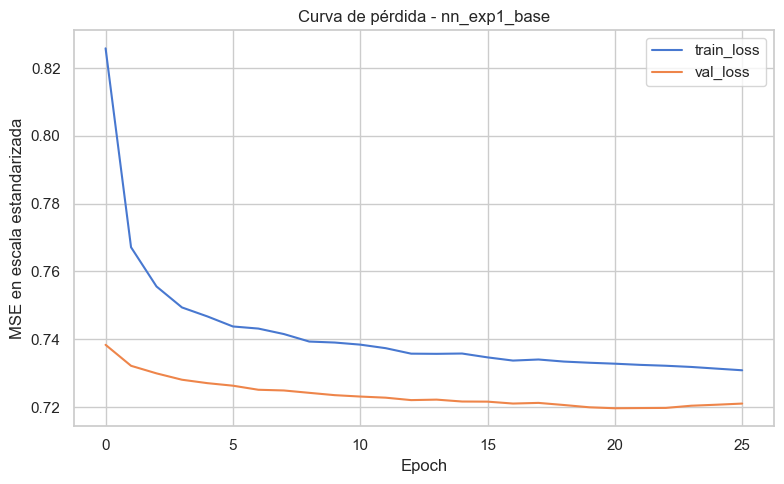

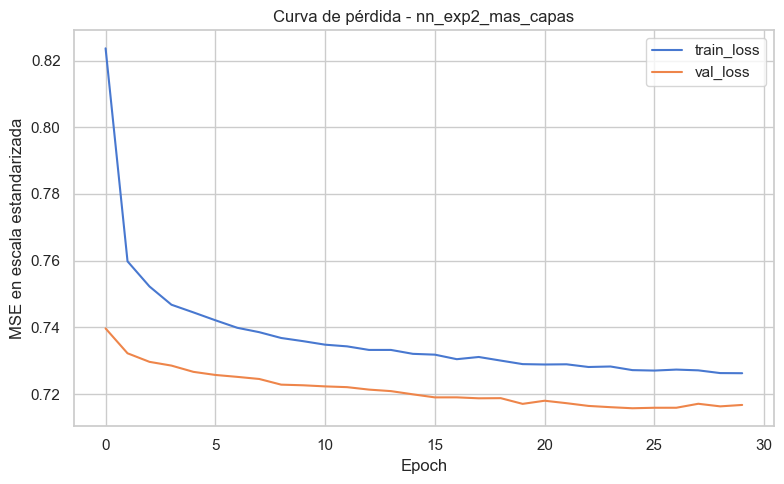

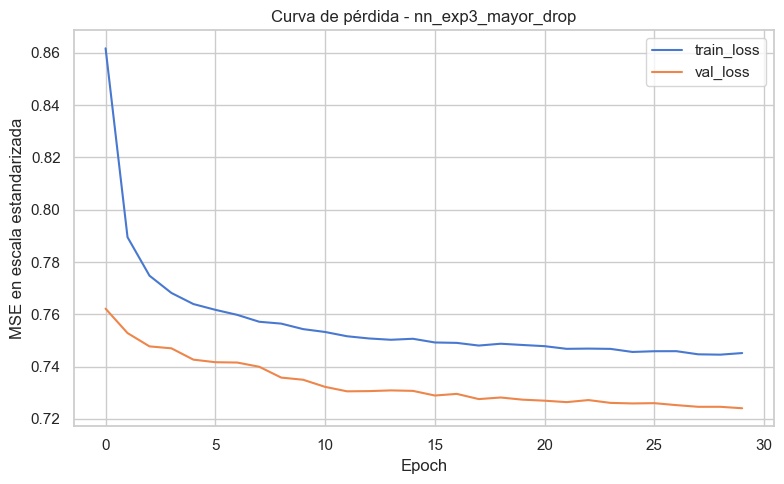

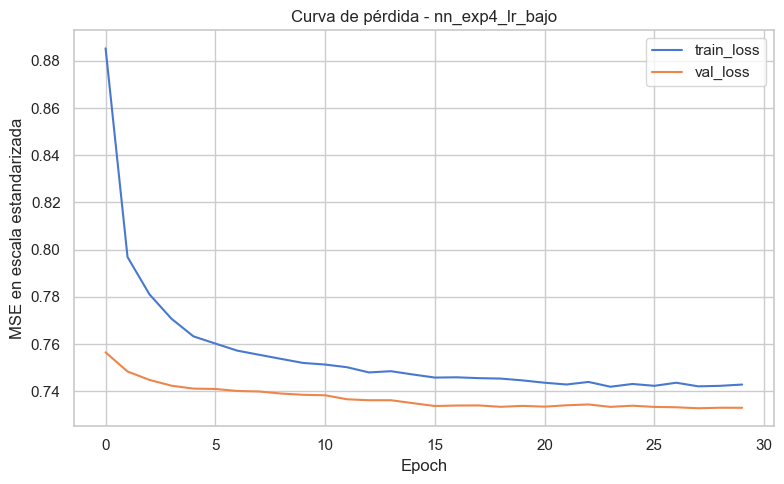

In [14]:
for nombre, info in resultados.items():
    hist = info['history']

    plt.figure(figsize=(8, 5))
    plt.plot(hist.history['loss'], label='train_loss')
    plt.plot(hist.history['val_loss'], label='val_loss')
    plt.title(f'Curva de pérdida - {nombre}')
    plt.xlabel('Epoch')
    plt.ylabel('MSE en escala estandarizada')
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / f'curva_perdida_{nombre}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 6. Modelo adicional de referencia

In [15]:
y_train_original = scaler_y.inverse_transform(y_train_tf).ravel()
y_test_eval = scaler_y.inverse_transform(y_test_tf).ravel()

hgb = HistGradientBoostingRegressor(
    max_iter=200,
    learning_rate=0.05,
    max_leaf_nodes=31,
    random_state=SEED
)

hgb.fit(X_train_tf, y_train_original)
pred_hgb = hgb.predict(X_test_tf)

metrics_hgb = regression_metrics(y_test_eval, pred_hgb)

print('HistGradientBoostingRegressor')
print(f"MAE:  {metrics_hgb['MAE']:.2f}")
print(f"RMSE: {metrics_hgb['RMSE']:.2f}")
print(f"R²:   {metrics_hgb['R2']:.4f}")

if USE_MLFLOW:
    mlflow.set_experiment('regresion_saber11_punt_global')
    with mlflow.start_run(run_name='baseline_hist_gradient_boosting'):
        mlflow.log_param('model_type', 'HistGradientBoostingRegressor')
        mlflow.log_param('max_iter', 200)
        mlflow.log_param('learning_rate', 0.05)
        mlflow.log_param('max_leaf_nodes', 31)
        for metric_name, metric_value in metrics_hgb.items():
            mlflow.log_metric(metric_name, float(metric_value))

HistGradientBoostingRegressor
MAE:  33.82
RMSE: 42.08
R²:   0.2945


### Comparación final

In [16]:
comparacion_final = pd.concat([
    df_comparacion_nn.assign(tipo_modelo='Red neuronal')[['tipo_modelo', 'experimento', 'MAE', 'RMSE', 'R2', 'epochs_trained']],
    pd.DataFrame([{
        'tipo_modelo': 'Modelo clásico',
        'experimento': 'baseline_hist_gradient_boosting',
        'MAE': metrics_hgb['MAE'],
        'RMSE': metrics_hgb['RMSE'],
        'R2': metrics_hgb['R2'],
        'epochs_trained': np.nan
    }])
], ignore_index=True).sort_values('RMSE').reset_index(drop=True)

comparacion_final

,tipo_modelo,experimento,MAE,RMSE,R2,epochs_trained
0,Modelo clásico,baseline_hist_gradient_boosting,33.817310,42.078089,0.294542,NaN
1,Red neuronal,nn_exp2_mas_capas,34.178532,42.399010,0.283740,30.0
2,Red neuronal,nn_exp1_base,34.279129,42.525509,0.279460,26.0
3,Red neuronal,nn_exp3_mayor_drop,34.467838,42.668438,0.274608,30.0
4,Red neuronal,nn_exp4_lr_bajo,34.750156,42.958084,0.264727,30.0


In [17]:
modelo_final_nombre = comparacion_final.loc[0, 'experimento']


## 7. Serialización de modelos y objetos de despliegue

In [18]:
# Guardar mejor red neuronal
best_nn_path = ARTIFACT_DIR / 'modelo_regresion_nn_saber11.keras'
best_nn.save(best_nn_path)

# Guardar baseline clásico
hgb_path = ARTIFACT_DIR / 'modelo_regresion_hgb_saber11.pkl'
joblib.dump(hgb, hgb_path)

# Guardar escaladores y mapas
joblib.dump(scaler_X, ARTIFACT_DIR / 'scaler_X.pkl')
joblib.dump(scaler_y, ARTIFACT_DIR / 'scaler_y.pkl')
joblib.dump(ORDINAL_MAPS, ARTIFACT_DIR / 'ordinal_maps.pkl')

# Guardar metadata útil para reporte/tablero
metadata = {
    'target': TARGET,
    'features': FEATURES,
    'best_neural_network': best_nn_name,
    'best_neural_network_params': best_nn_params,
    'best_neural_network_metrics': {k: float(v) for k, v in best_nn_metrics.items() if isinstance(v, (int, float, np.floating))},
    'hist_gradient_boosting_metrics': {k: float(v) for k, v in metrics_hgb.items()},
    'selected_by_rmse': modelo_final_nombre
}

with open(ARTIFACT_DIR / 'metadata_regresion.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

# Guardar tablas comparativas
ndigits = 4
df_comparacion_nn.round(ndigits).to_csv(ARTIFACT_DIR / 'comparacion_redes_neuronales.csv', index=False)
comparacion_final.round(ndigits).to_csv(ARTIFACT_DIR / 'comparacion_final_regresion.csv', index=False)

print('Archivos guardados en:', ARTIFACT_DIR.resolve())
print('- ', best_nn_path)
print('- ', hgb_path)
print('- ', ARTIFACT_DIR / 'scaler_X.pkl')
print('- ', ARTIFACT_DIR / 'scaler_y.pkl')
print('- ', ARTIFACT_DIR / 'metadata_regresion.json')

Archivos guardados en: /Users/jeronimoruedar/Desktop/Octavo Semestre/Analítica Computacional/Proyectos/P2/Proyecto-2/notebooks/artifacts_regresion
-  artifacts_regresion/modelo_regresion_nn_saber11.keras
-  artifacts_regresion/modelo_regresion_hgb_saber11.pkl
-  artifacts_regresion/scaler_X.pkl
-  artifacts_regresion/scaler_y.pkl
-  artifacts_regresion/metadata_regresion.json


## 8. Función de predicción para integrar al Dash

In [19]:
def preparar_input_regresion(input_dict, ordinal_maps=ORDINAL_MAPS, features=FEATURES):
    """Convierte un diccionario con categorías originales a un DataFrame numérico ordenado."""
    row = {}
    for feature in features:
        value = input_dict[feature]
        if feature in ordinal_maps:
            mapped = ordinal_maps[feature].get(value)
            if mapped is None:
                raise ValueError(f'Valor no reconocido para {feature}: {value}')
            row[feature] = mapped
        else:
            row[feature] = value
    return pd.DataFrame([row], columns=features)


def predecir_puntaje_nn(input_dict, model=best_nn, scaler_X=scaler_X, scaler_y=scaler_y):
    """Predice PUNT_GLOBAL usando la mejor red neuronal entrenada."""
    X_new = preparar_input_regresion(input_dict)
    X_new_sc = scaler_X.transform(X_new).astype('float32')
    pred_sc = model.predict(X_new_sc, verbose=0).ravel()[0]
    pred = scaler_y.inverse_transform([[pred_sc]])[0, 0]
    return float(pred)

# Ejemplo de uso para tablero
example_input = {
    'FAMI_ESTRATOVIVIENDA': 'Estrato 2',
    'FAMI_EDUCACIONPADRE': 'Secundaria (Bachillerato) completa',
    'FAMI_EDUCACIONMADRE': 'Secundaria (Bachillerato) completa',
    'FAMI_TIENEINTERNET': 'Si',
    'FAMI_TIENECOMPUTADOR': 'Si',
    'FAMI_TIENELAVADORA': 'Si',
    'COLE_BILINGUE': 'N',
    'COLE_JORNADA': 'MAÑANA',
    'COLE_NATURALEZA': 'OFICIAL',
    'COLE_AREA_UBICACION': 'URBANO'
}

pred_example = predecir_puntaje_nn(example_input)
print(f'Predicción ejemplo PUNT_GLOBAL: {pred_example:.1f}')

Predicción ejemplo PUNT_GLOBAL: 261.4


In [23]:
print(X_train_tf)
print(y_train_tf)
print(scaler_y)

[[-1.0690616e+00  1.8891726e-01 -4.2620343e-01 ...  2.9398134e-01
  -7.1079892e-01 -2.8963132e+00]
 [ 6.9889247e-01 -9.8770607e-01 -2.1416636e+00 ... -2.0026593e+00
  -7.1079892e-01  3.4526652e-01]
 [-1.0690616e+00 -9.8770607e-01 -8.5506845e-01 ... -8.5433900e-01
  -7.1079892e-01  3.4526652e-01]
 ...
 [-1.8508457e-01 -2.0329051e-01 -4.2620343e-01 ... -8.5433900e-01
  -7.1079892e-01  3.4526652e-01]
 [-1.8508457e-01  1.8891726e-01  2.6616072e-03 ... -8.5433900e-01
  -7.1079892e-01  3.4526652e-01]
 [-1.0690616e+00  1.8891726e-01  8.6039168e-01 ...  2.9398134e-01
  -7.1079892e-01  3.4526652e-01]]
[[ 0.10322633]
 [-0.9332762 ]
 [-0.17583203]
 ...
 [-1.1525363 ]
 [ 1.4586526 ]
 [-0.09610108]]
StandardScaler()


In [24]:
from sklearn.ensemble import HistGradientBoostingRegressor
import joblib
from pathlib import Path

y_train_eval = scaler_y.inverse_transform(
    y_train_tf.reshape(-1, 1)
).ravel()

hgb = HistGradientBoostingRegressor(
    max_iter=200,
    learning_rate=0.05,
    max_leaf_nodes=31,
    random_state=42
)

hgb.fit(X_train_tf, y_train_eval)

ARTIFACT_DIR = Path("artifacts_regresion")
ARTIFACT_DIR.mkdir(exist_ok=True)

joblib.dump(hgb, ARTIFACT_DIR / "modelo_regresion_hgb_saber11.pkl")

modelo_test = joblib.load(ARTIFACT_DIR / "modelo_regresion_hgb_saber11.pkl")
print("HGB reentrenado, guardado y cargado correctamente.")
print(modelo_test)

HGB reentrenado, guardado y cargado correctamente.
HistGradientBoostingRegressor(learning_rate=0.05, max_iter=200, random_state=42)
